In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kabure/german-credit-data-with-risk")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 11.2k/11.2k [00:00<00:00, 3.31MB/s]

Extracting files...
Path to dataset files: C:\Users\MOTE THE ANALYST\.cache\kagglehub\datasets\kabure\german-credit-data-with-risk\versions\1


In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [2]:
# Data set overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [85]:
df['Checking account'].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [3]:
# Checking the percentage of missing values
df.isna().sum()/len(df)*100

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64

In [4]:
df = df.dropna().reset_index(drop=True)
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [5]:
df.drop(columns='Unnamed: 0',inplace=True)

In [6]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

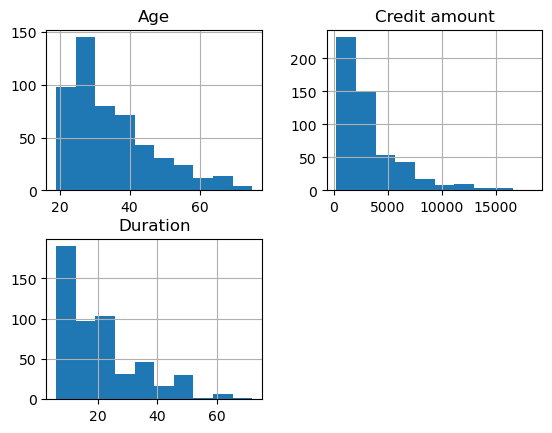

In [8]:
#Checking the distribution of numerical features: Age, Credit amount, Duration.
n_cols=["Age","Credit amount","Duration"]
_=df[n_cols].hist()

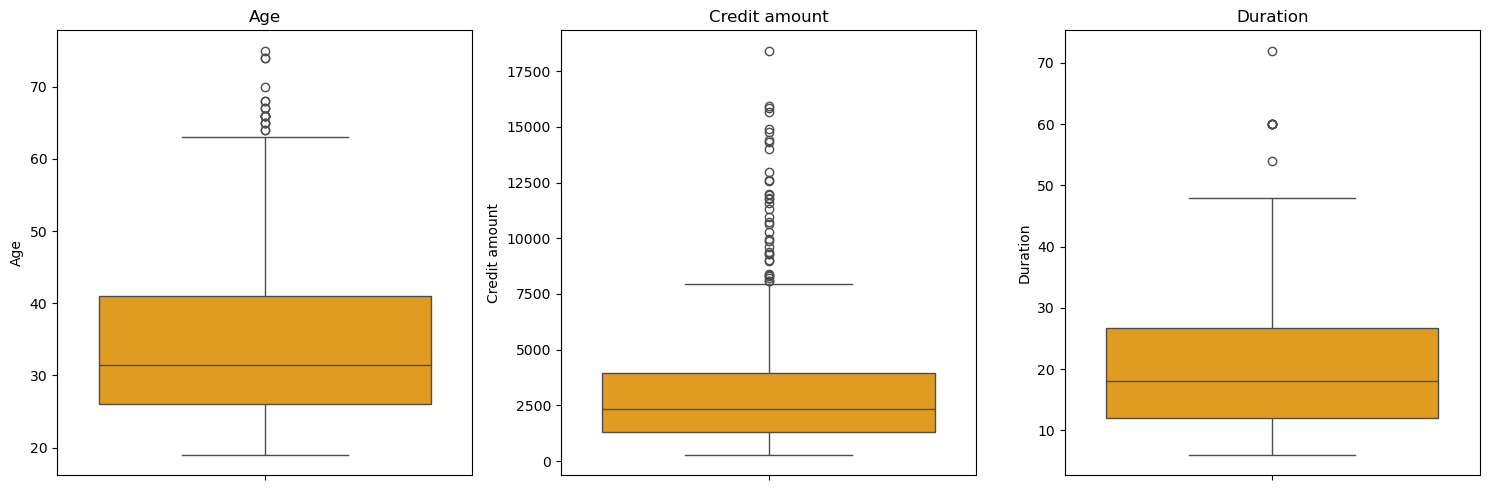

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# box plots of the numeric features for outlier detection
plt.figure (figsize = (15,5))
for i, col in enumerate(n_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color="orange")
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
df.query("Duration <=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


# Categorical Columns

In [12]:
c_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose','Risk' ]

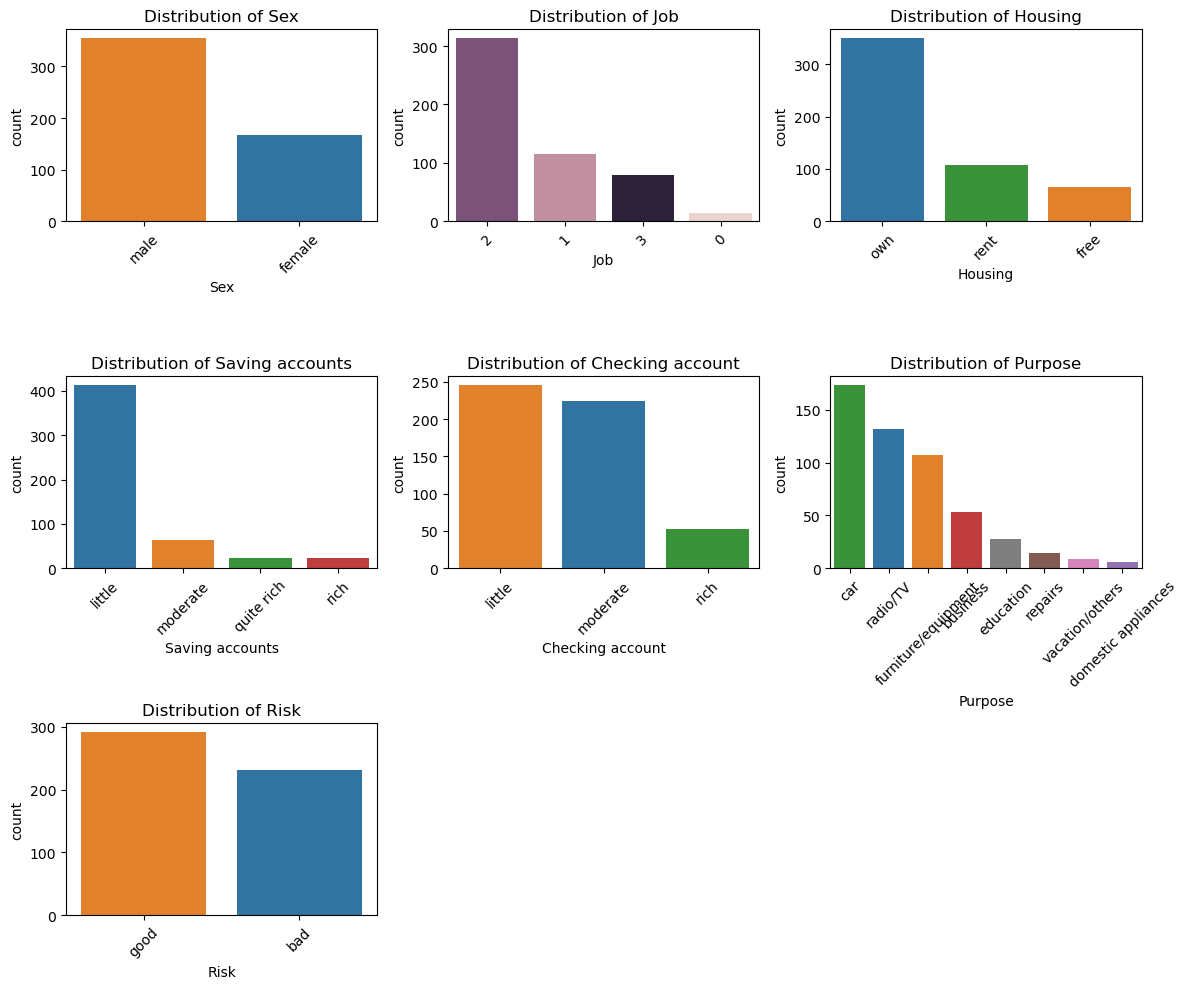

In [13]:
plt.figure(figsize=(12,10))
for i, col in enumerate(c_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue=col,legend=False,order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Checking the correlation metrix
corr = df[['Age','Job','Credit amount','Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


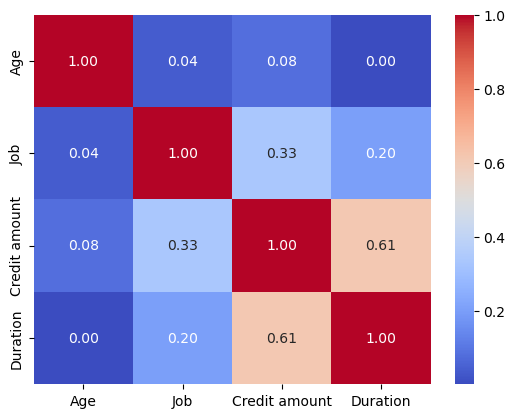

In [15]:
sns.heatmap(corr,annot=True,cmap ="coolwarm",fmt=".2f")
plt.show()

In [16]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [17]:
df.groupby('Sex')["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [18]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


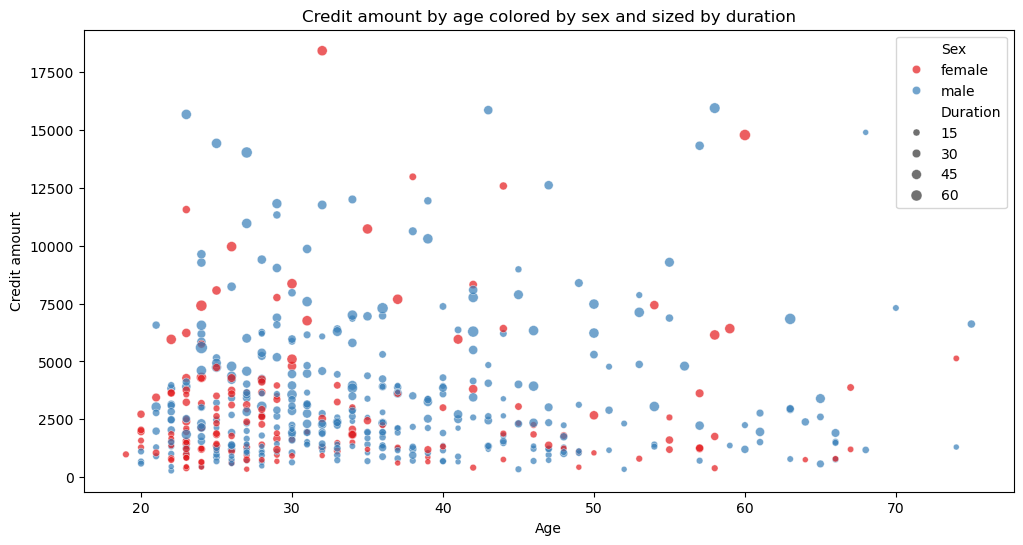

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='Age',y='Credit amount',hue='Sex',size='Duration',alpha=0.7,palette='Set1')
plt.title("Credit amount by age colored by sex and sized by duration")
plt.show()

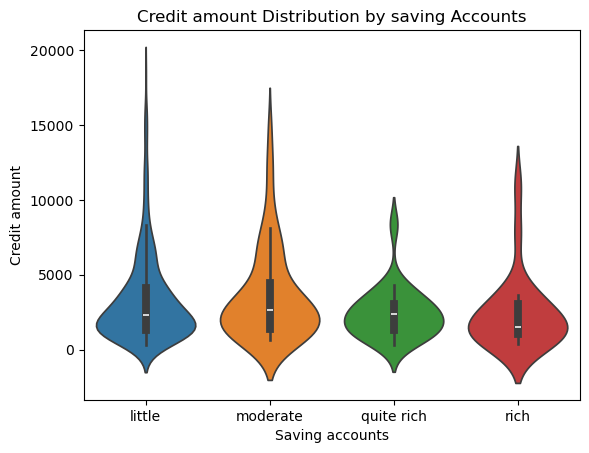

In [20]:
sns.violinplot(data=df,x='Saving accounts',y='Credit amount',hue='Saving accounts',legend=False)
plt.title("Credit amount Distribution by saving Accounts")
plt.show()

In [21]:
df['Risk'].value_counts(normalize=True)

Risk
good    0.557471
bad     0.442529
Name: proportion, dtype: float64

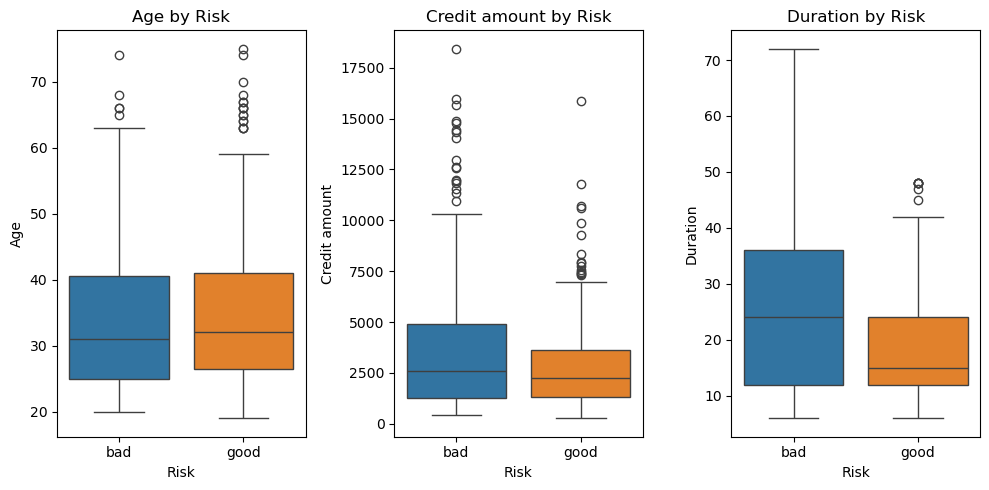

In [22]:
plt.figure(figsize=(10,5))
for i, col in enumerate(n_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col,hue="Risk",legend=False)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [25]:
df.groupby('Risk')[['Age','Credit amount','Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


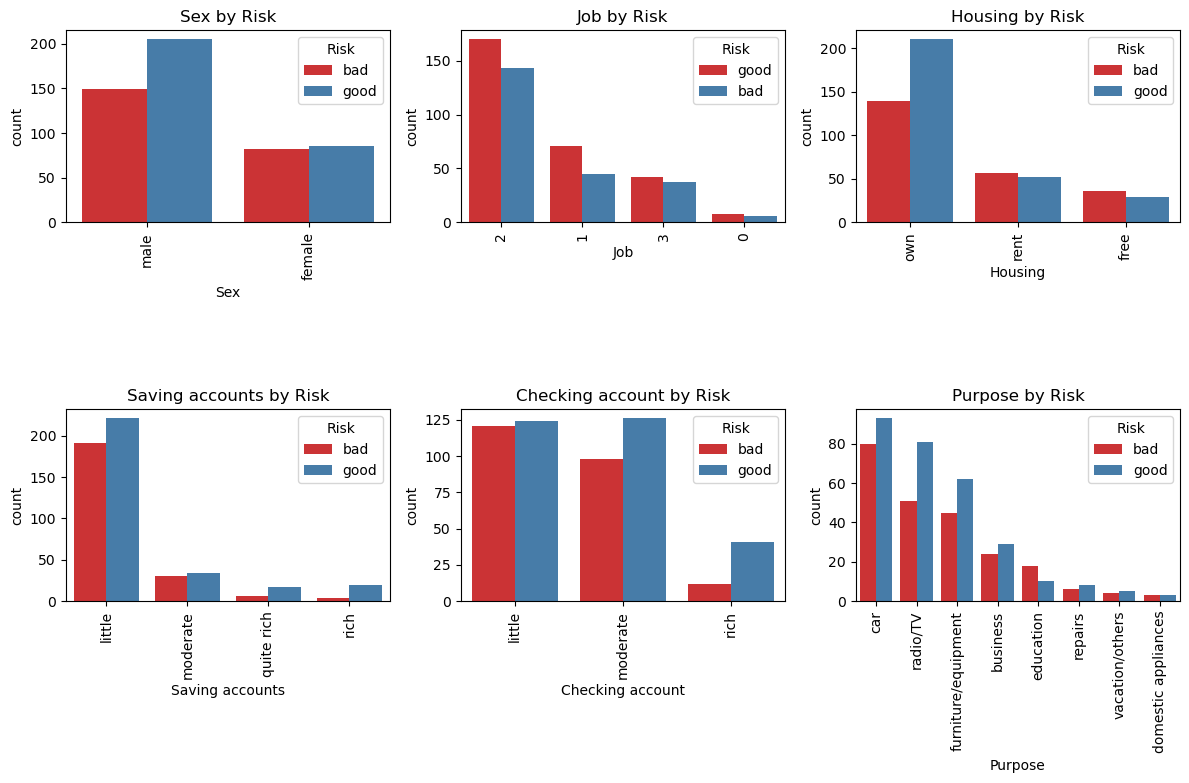

In [33]:
c_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']
plt.figure(figsize=(12,10))
for i, col in enumerate(c_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col,hue='Risk',palette='Set1',order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
    

# Building the Model

In [36]:
#Selecting features and target
features =['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Credit amount', 'Duration']
Target = 'Risk'

In [38]:
df_model = df[features + [Target]].copy()
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [86]:
df_model['Checking account'].unique()

array([1, 0, 2])

In [39]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [40]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

le_dict = {}
for col in cat_cols:
    le=LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le,f"{col}_encoder.pkl")

In [44]:
le_target = LabelEncoder()
df_model[Target] = le_target.fit_transform(df_model[Target])
df_model[Target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [45]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [49]:
from sklearn.model_selection import train_test_split

X = df_model.drop(Target, axis=1)
y= df_model[Target]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=1)


In [50]:
X_train.shape

(417, 8)

In [51]:
X_test.shape

(105, 8)

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [59]:
def train_model(model,param_grid,X_train,y_train, X_test,y_test):
    grid = GridSearchCV(model,param_grid, cv=5, scoring = "accuracy",n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_
    y_pred= best_model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    return best_model,acc, grid.best_params_

In [60]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = 'balanced' )
dt_param_grid = {
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [61]:
best_dt, acc_dt,params_dt = train_model(dt, dt_param_grid,X_train,y_train,X_test,y_test)

In [62]:
print("Decision tree accuracy", acc_dt)

Decision tree accuracy 0.580952380952381


In [63]:
print("Best parameters",params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [66]:
rf = RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)
rf_param_grid = {
    "n_estimators":[100,200],
    "max_depth": [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}
best_rf, acc_rf,params_rf = train_model(rf, rf_param_grid,X_train,y_train,X_test,y_test)

In [67]:
print("Random Foresy accuracy", acc_rf)


Random Foresy accuracy 0.6190476190476191


In [68]:
print("Best parameters",params_rf)

Best parameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [69]:
et = ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)
et_param_grid = {
    "n_estimators":[100,200],
    "max_depth": [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}
best_et, acc_et,params_et = train_model(et, et_param_grid,X_train,y_train,X_test,y_test)


In [70]:
print("Extra Trees Classifier accuracy", acc_et)

Extra Trees Classifier accuracy 0.6476190476190476


In [71]:
print("Best parameters",params_et)

Best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [79]:
xgb = XGBClassifier(random_state=1,scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),use_label_enconder=False,eval_metric="logloss")
xgb_param_grid = {
    "n_estimators":[100,200],
    "max_depth": [3, 5,7],
    "learning_rate" : [0.01,0.1,0.2],
    "subsample": [0.7,1],
    "colsample_bytree": [0.7,1]
}


In [80]:
best_xgb, acc_xgb,params_xgb = train_model(xgb, xgb_param_grid,X_train,y_train,X_test,y_test)

C:\Miniconda3\envs\timeseries\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:02:49] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_enconder" } are not used.

  warnings.warn(smsg, UserWarning)


In [76]:
print("XGBoost accuracy", acc_xgb)

XGBoost accuracy 0.6476190476190476


In [81]:
print("Best parameters",params_xgb)

Best parameters {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


# Exporting the best model

In [82]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']